```
# Linear Regression from Scratch
```

## **Todos**

* Regularization

## **Imports**

In [117]:
# !pip install seaborn

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression

import pickle

## **Load Dataset**

In [119]:
wine_df = pd.read_csv("./../Datasets/wine_quality/winequality-red.csv", sep=";")
X_wine, y_wine = wine_df.iloc[:, :-1].copy(), wine_df.iloc[:, -1]

In [120]:
X_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [121]:
y_wine.describe()

count    1599.000000
mean        5.636023
std         0.807569
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         8.000000
Name: quality, dtype: float64

target is continuous, so we can use linear regression

In [122]:
X_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
dtypes: float64(11)
memory usage: 137.5 KB


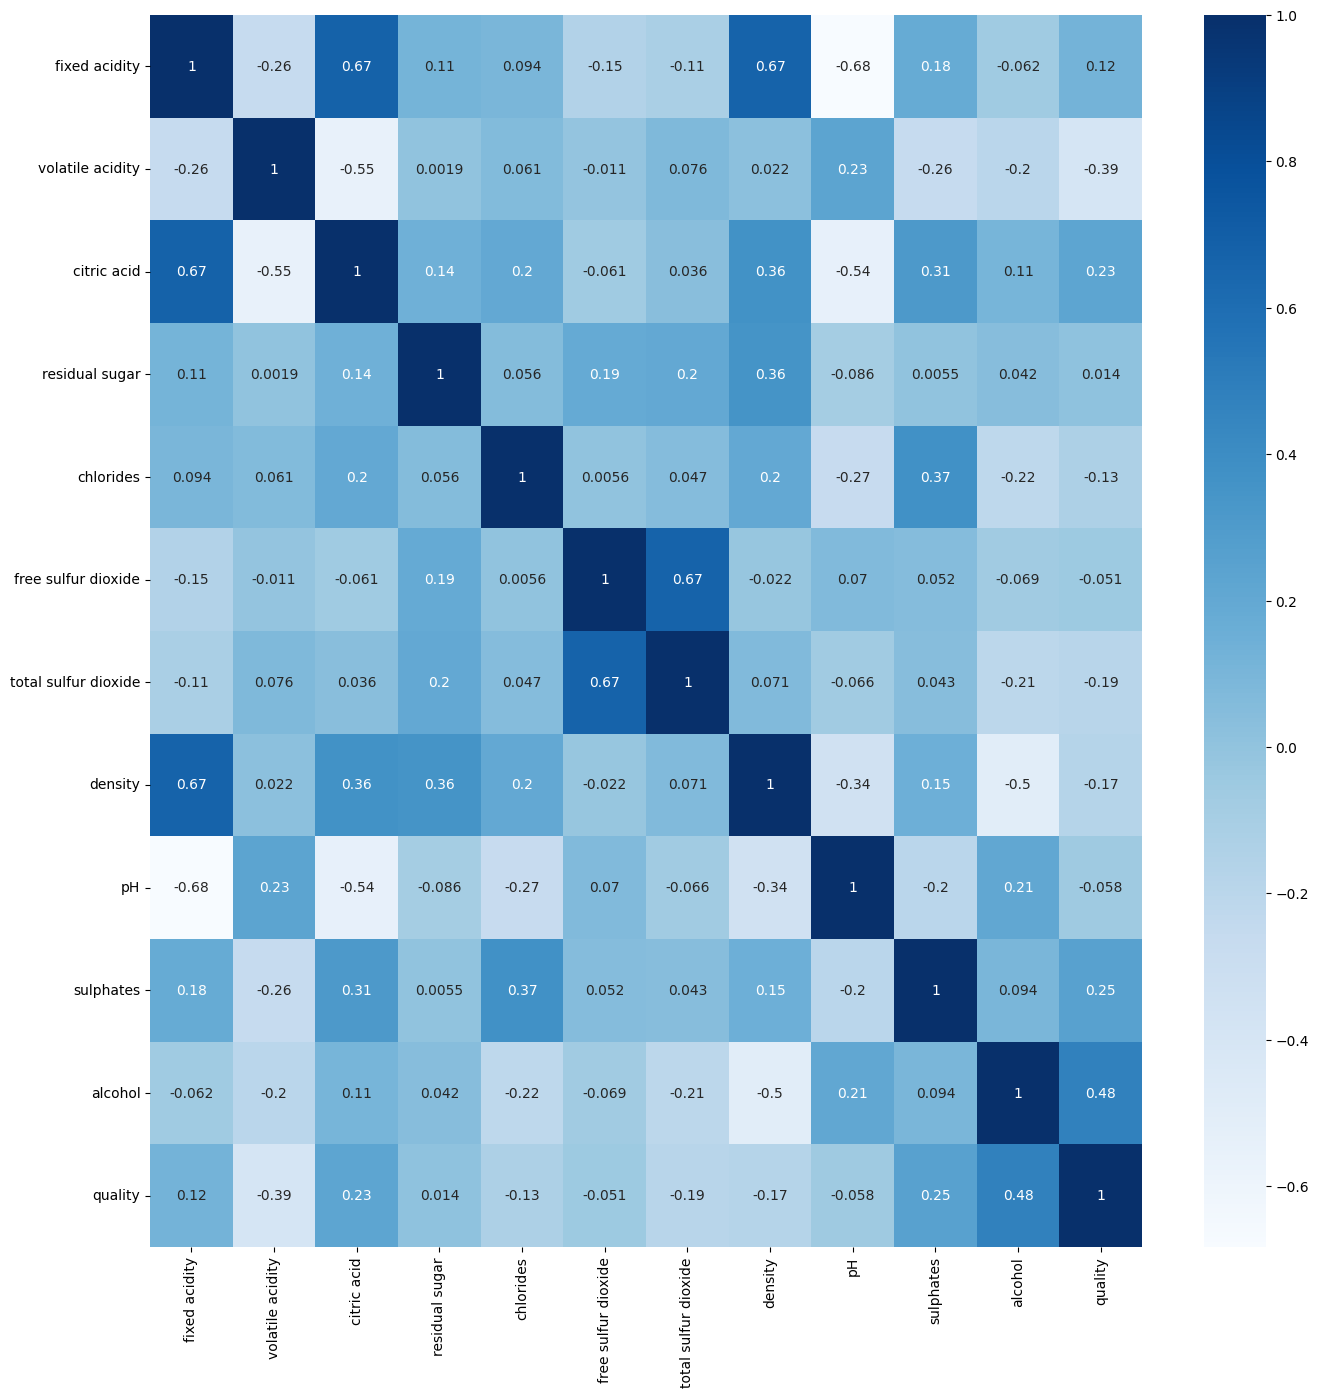

In [123]:
fig, ax = plt.subplots(figsize=(16, 16))
sns.heatmap(data=wine_df.corr(), annot=True, cmap="Blues", ax=ax)
plt.show()

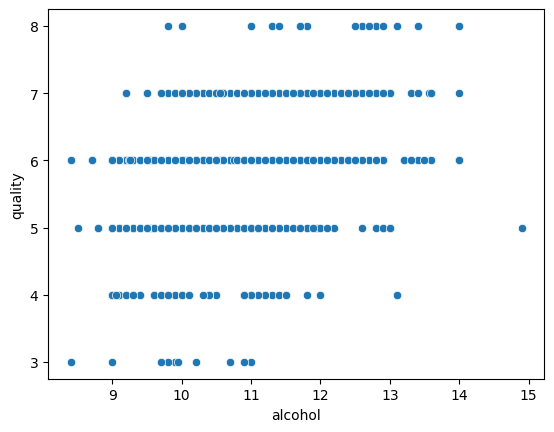

In [124]:
sns.scatterplot(x=X_wine["alcohol"], y=y_wine)
plt.show()

## **Preprocess Dataset**

In [125]:
X_train, X_test, y_train, y_test = train_test_split(X_wine, y_wine, test_size=0.2, random_state=42)

No need for validation set

In [126]:
scalar = StandardScaler()

X_train = pd.DataFrame(scalar.fit_transform(X_train), columns=X_wine.columns)
X_test = pd.DataFrame(scalar.transform(X_test), columns=X_wine.columns)

In [127]:
X_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.218332,0.889712,0.192092,0.309726,-0.049642,0.691007,1.042934,1.846696,1.093500,0.458223,1.123177
1,-1.290166,-1.788783,0.652753,-0.805080,-0.455214,2.388473,3.593870,-3.004491,-0.400439,-0.401197,1.408272
2,1.494753,-0.784347,1.011045,-0.526378,0.599272,-0.957960,-0.991742,0.768655,-0.075669,0.515517,-0.587390
3,0.276351,0.861811,-0.063831,-0.665729,-0.009085,0.012020,-0.718427,0.089488,0.054238,-1.088733,-0.967516
4,0.044274,2.814880,-0.626861,2.399985,-0.313264,-0.472970,0.222990,1.199871,0.379008,-0.974144,-0.492358


## **Global Functions**

In [138]:
def evaluate_model(model, X, y):
    """
    Evaluate model on test data with common regression metrics.

    Parameters:
        X (array-like): Test input features.
        y (array-like): True labels.

    Returns:
        dict: Dictionary with MSE, MAE, R².
    """
    y_pred = model.predict(X)
    return {
        "R2": r2_score(y, y_pred),
        "MSE": mean_squared_error(y, y_pred),
        "MAE": mean_absolute_error(y, y_pred),
    }

## **Linear Regression**

In [145]:
class LinearRegressionScratch:
    """
    Linear Regression Model using Gradient Descent (from scratch)

    This class implements a linear regression model trained using batch gradient descent.
    It supports training with early stopping, cost tracking, model evaluation, and saving/loading.

    Parameters:
        X (array-like): Feature matrix of shape (n_samples, n_features).
        y (array-like): Target vector of shape (n_samples,).
        lr (float, optional): Learning rate for gradient descent. Default is 0.1.
        epoch (int, optional): Maximum number of training iterations (epochs). Default is 200.
        verbose (bool, optional): Whether to print cost every 100 epochs. Default is False.
        tolerance (float, optional): Minimum improvement in cost to continue training (for early stopping). Default is 1e-6.
        plot_cost (bool, optional): Whether to plot cost curve after training. Default is False.

    Attributes:
        ws (numpy.ndarray): Current weights (updated during training).
        b (float): Current bias term.
        best_ws (numpy.ndarray): Best weights (based on lowest cost during training).
        best_b (float): Best bias term.
        best_cost (float): Lowest cost observed during training.

    Methods:
        _compute_cost(): Computes mean squared error (MSE) cost.
        _gradient_descent(): Performs one iteration of gradient descent.
        fit(): Trains the model using gradient descent and tracks best weights.
        predict(data): Predicts target values for input features.
        evaluate(X, y): Returns performance metrics (MSE, MAE, R²) on test data.
        save_model(filename): Saves the model parameters to a pickle file.
        load_model(filename): Loads model parameters from a pickle file.

    Example:
        >>> model = LinearRegressionScratch(X=X_train, y=y_train, lr=0.1, epoch=1000,
                                            tolerance=1e-6, verbose=False, plot_cost=False)
        >>> model.fit()
        >>> predictions = model.predict(X_test)
        >>> metrics = model.evaluate(X_test, y_test)
        >>> model.save_model("my_model.pkl")
        >>> model.load_model("my_model.pkl")
    """
    
    def __init__(self,
                 X, y,
                 lr: float=0.1,
                 epoch: int=200,
                 verbose: bool=False,
                 tolerance=1e-6,
                 plot_cost: bool=False
                ):
        """
        Initialize the LinearRegressionBasic model.

        Parameters:
            X (array-like): Feature matrix of shape (n_samples, n_features).
            y (array-like): Target vector of shape (n_samples,).
            lr (float): Learning rate for gradient descent.
            epoch (int): Number of training iterations (epochs).
            verbose (bool): Log training progress every few epochs.
            tolerance: Early stopping if the cost improvement falls below a threshold.
            plot_cost (bool): Whether to plot the cost over iterations.
        """
        self.lr = lr
        self.ws = np.random.randn(X.shape[1]) * 0.01
        self.b = 0
        self.epoch = epoch
        self.verbose = verbose
        self.tolerance = tolerance
        self.plot_cost = plot_cost

        self.X = np.array(X)
        self.y = np.array(y)
        
        self.best_ws = None
        self.best_b = None
        self.best_cost = float("inf")

    def _compute_cost(self) -> None:
        """
        Compute the mean squared error (MSE) cost.

        Returns:
            float: The MSE cost between predicted and actual values.
        """
        y_pred = np.dot(self.X, self.ws) + self.b
        return mean_squared_error(self.y, y_pred)

    def _gradient_descent(self) -> None:
        """
        Perform one step of batch gradient descent to update weights and bias.
        """
        n = len(self.y)
        y_pred = np.dot(self.X, self.ws) + self.b
        error = y_pred - self.y

        dw = (1 / n) * np.dot(self.X.T, error)
        db = (1 / n) * np.sum(error)

        self.ws -= self.lr * dw
        self.b -= self.lr * db
    
    def fit(self) -> None:
        """
        Train the linear regression model using gradient descent.

        Stores the best weights and bias based on lowest MSE during training.
        Optionally plots the cost curve if `plot_cost` is True.
        """
        costs = []
        
        # Training loop
        for epoch in range(self.epoch):
            self._gradient_descent()
            cost = self._compute_cost()

            if self.verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}: Cost = {cost:.4f}")
        
            if cost < self.best_cost:
                if self.best_cost - cost < self.tolerance:
                    break
                self.best_cost = cost
                self.best_ws = self.ws.copy()
                self.best_b = self.b

            costs.append(cost)

        if self.plot_cost and costs:
            plt.figure(figsize=(8, 4))
            sns.lineplot(x=range(len(costs)), y=costs)
            plt.title("Cost vs Epoch")
            plt.xlabel("Epoch")
            plt.ylabel("MSE")
            plt.grid(True)
            plt.show()

    def predict(self, data) -> np.ndarray:
        """
        Predict target values for new input data using the best learned weights.

        Parameters:
            data (array-like): Input data of shape (m, n_features).

        Returns:
            numpy.ndarray: Predicted target values of shape (m,).
        """
        if self.best_ws is None or self.best_b is None:
            raise ValueError("Model not fitted!")

        y_pred = np.dot(data, self.best_ws) + self.best_b
        return y_pred
                

    def evaluate(self, X, y):
        """
        Evaluate model on test data with common regression metrics.
    
        Parameters:
            X (array-like): Test input features.
            y (array-like): True labels.
    
        Returns:
            dict: Dictionary with MSE, MAE, R².
        """
        y_pred = self.predict(X)
        return {
            "R2": r2_score(y, y_pred),
            "MSE": mean_squared_error(y, y_pred),
            "MAE": mean_absolute_error(y, y_pred),
        }

    def save_model(self, filename='linear_model.pkl'):
        import pickle
        with open(filename, 'wb') as f:
            pickle.dump({'weights': self.best_ws, 'bias': self.best_b}, f)
    
    def load_model(self, filename):
        import pickle
        with open(filename, 'rb') as f:
            model = pickle.load(f)
            self.best_ws = model['weights']
            self.best_b = model['bias']    

### Sklearn Model vs Above

In [147]:
%%time
lr_model = LinearRegressionScratch(X=X_train, y=y_train, lr=0.1, epoch=1000,
                                   tolerance=1e-6, verbose=False, plot_cost=False)
lr_model.fit()
y_pred = lr_model.predict(X_test)
lr_model.evaluate(X_test, y_test)

CPU times: total: 172 ms
Wall time: 185 ms


{'R2': 0.4034191641933603,
 'MSE': 0.3898690717904739,
 'MAE': 0.5034840376354524}

In [148]:
%%time
lr_sk_model = LinearRegression()
lr_sk_model.fit(X_train, y_train)
y_pred_sk = lr_sk_model.predict(X_test)

evaluate_model(lr_sk_model, X_test, y_test)

CPU times: total: 15.6 ms
Wall time: 7.94 ms


{'R2': 0.4031803412796219,
 'MSE': 0.39002514396395493,
 'MAE': 0.5035304415524375}